## human play metapop1

Incoming dispersal weights from occupied patches (from persisting/from all):
incoming_weights[0]: 1.71/2.07
incoming_weights[1]: 1.07/1.21
incoming_weights[2]: 2.78/2.92
incoming_weights[3]: 0.51/0.69
incoming_weights[4]: 2.12/2.81
incoming_weights[5]: 1.52/1.85
incoming_weights[6]: 1.91/2.55
incoming_weights[7]: 1.46/1.81
incoming_weights[8]: 0.76/1.20
incoming_weights[9]: 2.03/2.90


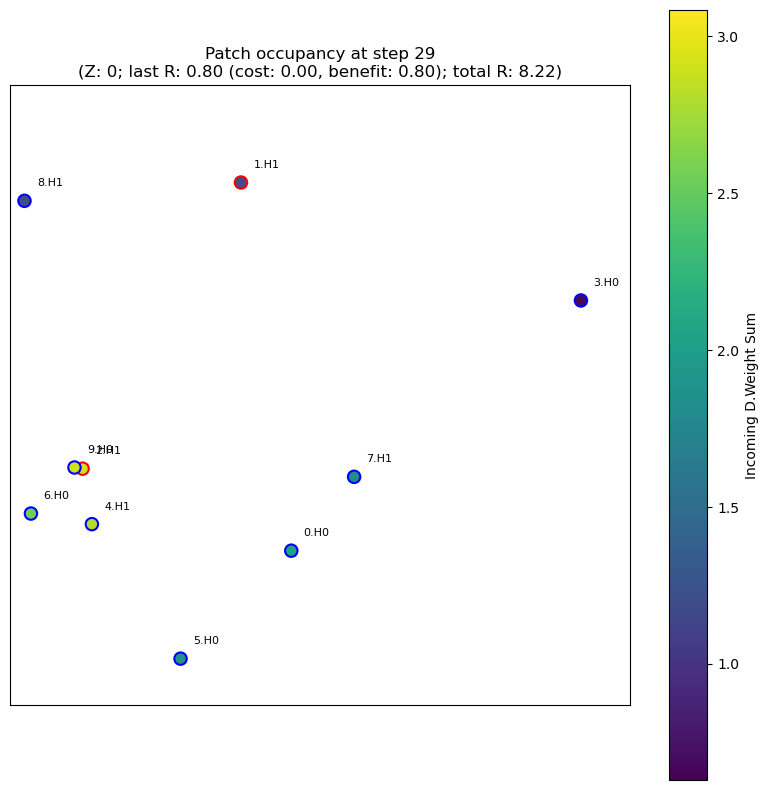

patch num = 10
Total reward: 8.62
Average connectivity: 1.51, Average extinction prob: 0.26, Average colonization prob: 0.16
Occupied fraction: Avg 0.77, Std 0.14
Good habitat fraction: Avg 0.80, Std 0.14
survival time: 30


In [ ]:
# performance testing for metapop1
from IPython.display import display, clear_output
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import copy
import random
import torch
import pickle
import os
import datetime
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def humanplay_metapop1(env, config, RLsave = False):
    if RLsave:
        device = torch.device('cpu')  # Force CPU usage
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # find filename that starts with bestPolicyNetwork
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyNetwork"):
                model_path = os.path.join(wd, filename)
                break
        Policy = torch.load(model_path, map_location=device, weights_only=False)
        # find filename that starts with bestPolicyrms
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyrms"):
                rms_path = os.path.join(wd, filename)
                break
        with open(rms_path, "rb") as f:
            rms = pickle.load(f)

        # re-initialize the environment
        with open(f'{wd}/config.txt', 'r') as f:
            lines = f.readlines()
        for line in lines:
            if 'envconfig' in line:
                obsvarline = line
                break
        envconfigstr = obsvarline.split('envconfig: ')[1].strip()
        envconfigdict = eval(envconfigstr)
        env = metapop1(envconfigdict)

    # load patch coordinates once (same index as dispersalID)
    with open(f"./dispersal_weights/uniform_dispersal_coords_patchnum{env.patchnum}.pkl", "rb") as f:
        coords_all = pickle.load(f)
    with open(f"./dispersal_weights/uniform_dispersal_weights_patchnum{env.patchnum}.pkl", "rb") as f:
        weights_all = pickle.load(f)
    coords = coords_all[env.dispersalID]
    # Compute a fixed color scale across all selected samples
    incoming_min = np.inf
    incoming_max = -np.inf
    for sample_id in range(len(weights_all)):  # Loop through all samples
        incoming_weights = np.sum(weights_all[sample_id], axis=0)
        incoming_min = min(incoming_min, incoming_weights.min())
        incoming_max = max(incoming_max, incoming_weights.max())

    weigths = weights_all[env.dispersalID]
    weightsum = np.sum(weigths, axis=1)


    # start simulation
    ## initialize containers for results
    obs, state = env.reset()
    obsinput = obs.copy()
    if RLsave:
        obsinput = rms.normalize(obsinput)
    done = False
    rewards = []
    avgconnectivity_per_episode = []
    avgeprob_per_episode = []
    avgcprob_per_episode = []
    occfraction_per_episode = []
    goodHfraction_per_episode = []
    survivaltime_per_episode = []
    restore_fraction_per_episode = []
    supp_fraction_per_episode = []
    tt=0
    RLactions = []
    RLactions_prob = []
    actions = []
    states = []
    observations = []
    envcheckpoints = []
    last_reward = 0
    totalbenefit = 0
    totalcost = 0
    ## main loop
    while not done:
        # save 
        states.append(env.state)
        observations.append(obs)
        envcheckpoints.append(copy.deepcopy(env)) # save environment

        ## plot and print current state
        # current occupancy for coloring
        if env.dim2state == 1:
            X = env.state[:, env.sidx["X"]]
            H = env.state[:, env.sidx["H"]]
            t = int(env.state[0, env.sidx["t"]])
        else:
            X = env.state[env.sidx["X"]]
            H = env.state[env.sidx["H"]]
            t = int(env.state[env.sidx["t"]][0])
        if env.dispersal_regime == 1:
            Z = env.state[0,env.sidx["Z"]] if env.dim2state == 1 else env.state[env.sidx["Z"]][0]
        else: 
            Z = 0

        # replace previous plot
        clear_output(wait=True)
        incoming_w = np.matmul(env.w, X)
        print('Incoming dispersal weights from occupied patches (from persisting/from all):')
        for i in range(env.patchnum):
            print(f'incoming_weights[{i}]: {incoming_w[i]:.2f}/{env.incoming_w[i]:.2f}')
        fig, ax = plt.subplots(figsize=(10, 10))
        edge_colors = np.where(X >= 0.5, "blue", "red")
        scatter = ax.scatter(coords[:, 0], coords[:, 1], c=weightsum, cmap="viridis", vmin=incoming_min, vmax=incoming_max, s=80, edgecolors=edge_colors, linewidths=1.5)
        cbar = plt.colorbar(scatter, ax=ax, label="Incoming D.Weight Sum")
        for i, (x, y) in enumerate(coords):
            ax.text(x + 0.02, y + 0.02, f'{i}.H{int(H[i])}', fontsize=8, ha="left", va="bottom", color="black")
        ax.set_title(f"Patch occupancy at step {t}\n(Z: {Z}; last R: {last_reward:.2f} (cost: {totalcost:.2f}, benefit: {totalbenefit:.2f}); total R: {np.sum(rewards):.2f})")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", "box")
        ax.set_xticks([])
        ax.set_yticks([])
        display_handle = display(fig, display_id=True)
        plt.close(fig)



        # calculate RL action
        if RLsave:
            with torch.no_grad():
                tensorobsinput = torch.tensor(obsinput, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                RLaction = Policy.getaction(tensorobsinput, get_action_only=True)
                RLaction = torch.squeeze(RLaction).cpu().detach().numpy()
                RLaction_prob = Policy.getaction(tensorobsinput, get_action_prob=True)
                RLaction_prob = torch.squeeze(RLaction_prob).cpu().detach().numpy()
            RLactions.append(RLaction)
            RLactions_prob.append(RLaction_prob)
        # get human action
        correctinput = False
        while correctinput == False:
            try:
                userinput = input(f'SUPPLEMENTATION: enter index of patches to supplement (0-{env.patchnum-1}), separated by comma, e.g. 0,3,4. Each patch cost {env.cs} \n Max number of patches allowed to supply: {env.kS}')
                userinput = np.array([s.strip() for s in userinput.replace('.', ',').split(',') if s.strip() != ''], dtype=np.int32)
                correctinput = True
            except:
                print('invalid input, try again',flush=True)
                continue
            if np.any(userinput<0) or np.any(userinput>=env.patchnum) or len(userinput) > env.kS:
                print('invalid input, try again',flush=True)
                correctinput = False
                continue
        actionS = np.zeros(env.patchnum, dtype=np.int32)
        actionS[userinput] = 1
        correctinput = False
        while correctinput == False:
            try:
                userinput2 = input(f'RESTORATION: enter index of patches to restore (0-{env.patchnum-1}), separated by comma, e.g. 0,3,4. Each patch cost {env.cr} \n Max number of patches allowed to restore: {env.kR}')
                userinput2 = np.array([s.strip() for s in userinput2.replace('.', ',').split(',') if s.strip() != ''], dtype=np.int32)
                correctinput = True
            except:
                print('invalid input, try again',flush=True)
                continue
            if np.any(userinput2<0) or np.any(userinput2>=env.patchnum) or len(userinput2) > env.kR:
                print('invalid input, try again',flush=True)
                correctinput = False
                continue
        
        actionR = np.zeros(env.patchnum, dtype=np.int32)
        actionR[userinput2] = 1
        action = np.concatenate([actionR,actionS])
        if env.state[0, env.sidx["t"]] >= env.T -2:
            action[:] = 0
             # no action in the last two steps to save time
        actions.append(action)
        #print(f'aS ({len(action[env.aidx["aS"]])}): {action[env.aidx["aS"]]}, aR ({len(action[env.aidx["aR"]])}): {action[env.aidx["aR"]]}')

        # step through the environment
        tt += 1
        obs, reward, done, info = env.step(action)
        totalcost = info['total_cost']
        totalbenefit = info['total_benefit']
        obsinput = env.obs.copy()
        if RLsave:
            obsinput = rms.normalize(obsinput)
        last_reward = reward

            
        # save results
        rewards.append(reward)
        avgconnectivity_per_episode.append(np.mean(info['connectivity']))
        avgeprob_per_episode.append(np.mean(info['extinction_prob']))
        avgcprob_per_episode.append(np.mean(info['colonization_prob']))
        occfraction_per_episode.append(np.mean(info['occupied_fraction']))
        goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
        restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
        supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)

        
    # save output as pickle
    output = {'rewards': rewards, 'total_rewards': np.sum(rewards), 'states': states, 'observations': observations,
              'actions': actions, 'RLactions': RLactions, 'RLactions_prob': RLactions_prob, 'numsteps': tt, 'envcheckpoints': envcheckpoints,
              'avgconnectivity_per_episode': avgconnectivity_per_episode, 'avgeprob_per_episode': avgeprob_per_episode, 'avgcprob_per_episode': avgcprob_per_episode,
              'occfraction_per_episode': occfraction_per_episode, 'goodHfraction_per_episode': goodHfraction_per_episode, 
              'restore_fraction_per_episode': restore_fraction_per_episode, 'supp_fraction_per_episode': supp_fraction_per_episode}
    
    with open(f"./human_play_results/human_play_{env.envID}_{env.settingID}_RLparam{(config['ppoparamset'] if RLsave else 'xx')}_RLseed{(config['pposeed'] if RLsave else 'xx')}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pkl", "wb") as f:
        pickle.dump(output, f)

    print(f'patch num = {env.patchnum}')
    print(f'Total reward: {np.sum(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity_per_episode):.2f}, Average extinction prob: {np.mean(avgeprob_per_episode):.2f}, Average colonization prob: {np.mean(avgcprob_per_episode):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction_per_episode):.2f}, Std {np.std(occfraction_per_episode):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction_per_episode):.2f}, Std {np.std(goodHfraction_per_episode):.2f}')
    print(f'survival time: {tt}')
    

    return output



# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics
# n=20 -> seednum = 252358, paramid = 34, parid = 11, setid = 21 
# n=10 -> seednum = 398845, paramid = 32, parid = 10, setid = 20
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22
# n=10 high centrality -> seednum = 444253, paramid = 36, parid = 10, setid = 23
# n=5 -> seednum = 578396, paramid = 30, parid = 9, setid = 18

# (2) n=20 -> seednum = 799891, paramid = 41, parid = 11, setid = 28 
# (2) n=10 -> seednum = 299436, paramid = 39, parid = 10, setid = 26
# (2) n=10 low centrality -> seednum = 125187, paramid = 43, parid = 10, setid = 30
# (2) n=10 high centrality -> seednum = 128500, paramid = 45, parid = 10, setid = 32
# (2) n=5 -> seednum = 255637, paramid = 37, parid = 9, setid = 24

# (3) n=20 -> seednum = XXXXX, paramid = 42, parid = 11, setid = 29 
# (3) n=10 -> seednum = 299436, paramid = 40, parid = 10, setid = 26
# (3) n=10 low centrality -> seednum = 554791, paramid = 44, parid = 10, setid = 31
# (3) n=10 high centrality -> seednum = 688063, paramid = 46, parid = 10, setid = 33
# (3) n=5 -> seednum = 82355, paramid = 38, parid = 9, setid = 25

config = {'ppoparamset':36,'pposeed':444253} 
settings = {'settingID': 23} # 18: n=5, 20: n=10, 21: n=20, 22: n=10 low centrality, 23: n=10 high centrality
env = metapop1(settings)

output = humanplay_metapop1(env,config=config,RLsave=True)


In [ ]:
import matplotlib.pyplot as plt
import os
import pickle
wd = './human_play_results'
# get all file names that has metapop1_{envsetting}
envsetting = 18
files = [f for f in os.listdir(wd) if f"metapop1_{envsetting}" in f]
totr = []
for f in files:
    with open(os.path.join(wd, f), 'rb') as file:
        data = pickle.load(file)
        totr.append(data['total_rewards'])


plt.hist(totr, bins=20)        
plt.title(f'Total rewards of human players on metapop1 setting {envsetting}, avg total reward: {np.mean(totr):.2f}')



In [ ]:
# replace RLactions with new RL policy.
import pickle
import torch
import os
import datetime
# rl to replace 

# n=20 -> seednum = 252358, paramid = 34, parid = 11, setid = 21 
# n=10 -> seednum = 398845, paramid = 32, parid = 10, setid = 20
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22
# n=10 high centrality -> seednum = 444253, paramid = 36, parid = 10, setid = 23
# n=5 -> seednum = 578396, paramid = 30, parid = 9, setid = 18

# (2) n=20 -> seednum = 799891, paramid = 41, parid = 11, setid = 28 
# (2) n=10 -> seednum = 299436, paramid = 39, parid = 10, setid = 26
# (2) n=10 low centrality -> seednum = 125187, paramid = 43, parid = 10, setid = 30
# (2) n=10 high centrality -> seednum = 128500, paramid = 45, parid = 10, setid = 32
# (2) n=5 -> seednum = 255637, paramid = 37, parid = 9, setid = 24

# (3) n=20 -> seednum = XXXXX, paramid = 42, parid = 11, setid = 29 
# (3) n=10 -> seednum = 299436, paramid = 40, parid = 10, setid = 26
# (3) n=10 low centrality -> seednum = 554791, paramid = 44, parid = 10, setid = 31
# (3) n=10 high centrality -> seednum = 688063, paramid = 46, parid = 10, setid = 33
# (3) n=5 -> seednum = 82355, paramid = 38, parid = 9, setid = 25

seednum = 252358
paramid = 34
parid = 11
setid = 21
RLfilename = f"./PPO_results/good_ones/seed{seednum}_paramid{paramid}/bestPolicyNetwork_metapop1_par{parid}_set{setid}_PPO2.pt"
device = torch.device('cpu')
RLPolicy = torch.load(RLfilename, map_location=device, weights_only=False)
rmsfilename = f"./PPO_results/good_ones/seed{seednum}_paramid{paramid}/bestPolicyrms_metapop1_par{parid}_set{setid}_PPO2.pkl"
with open(rmsfilename, "rb") as f:
    rms = pickle.load(f)

# get all filenames in human_play_results folder
files = os.listdir('./human_play_results')
for filename in files:
    if f'human_play_metapop1_{setid}' in filename:
        with open(os.path.join('./human_play_results', filename), 'rb') as f:
            data = pickle.load(f)
        datetimestamp = f'{filename.split('_')[-2]}_{filename.split('_')[-1].split('.')[0]}'
    else:
        continue
    # go thorugh every env checkpoint and replace the RL action with the action from the loaded RL policy
    new_RLactions = []
    new_RLactions_prob = []
    for i in range(len(data['envcheckpoints'])):
        env = data['envcheckpoints'][i]
        obs = data['observations'][i]
        obsinput = rms.normalize(obs)
        with torch.no_grad():
            tensorobsinput = torch.tensor(obsinput, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
            RLaction = RLPolicy.getaction(tensorobsinput, get_action_only=True)
            RLaction = torch.squeeze(RLaction).cpu().detach().numpy()
            RLaction_prob = RLPolicy.getaction(tensorobsinput, get_action_prob=True)
            RLaction_prob = torch.squeeze(RLaction_prob).cpu().detach().numpy()
        new_RLactions.append(RLaction)
        new_RLactions_prob.append(RLaction_prob)

    # save the new RL actions in the data dictionary and save it as a new pickle file
    data['RLactions'] = new_RLactions
    data['RLactions_prob'] = new_RLactions_prob
    with open(os.path.join('./human_play_results', f"human_play_metapop1_{setid}_RLparam{paramid}_RLseed{seednum}_{datetimestamp}.pkl"), 'wb') as f:
        pickle.dump(data, f)




In [5]:
# watch RL or heuristics play
from IPython.display import display, clear_output
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import copy
import random
import torch
import pickle
import os
import datetime
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def RLheuristicplay_metapop1(env, config, RLsave = False, heuristic = True, heuristic_saveid = None, heuristic_save = False, heuristic_type = 1, displayview = False,printout=True):
    if RLsave:
        device = torch.device('cpu')  # Force CPU usage
        if printout:
            print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # find filename that starts with bestPolicyNetwork
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyNetwork"):
                model_path = os.path.join(wd, filename)
                break
        Policy = torch.load(model_path, map_location=device, weights_only=False)
        # find filename that starts with bestPolicyrms
        for filename in os.listdir(wd):
            if filename.startswith("bestPolicyrms"):
                rms_path = os.path.join(wd, filename)
                break
        with open(rms_path, "rb") as f:
            rms = pickle.load(f)

        # re-initialize the environment
        with open(f'{wd}/config.txt', 'r') as f:
            lines = f.readlines()
        for line in lines:
            if 'envconfig' in line:
                obsvarline = line
                break
        envconfigstr = obsvarline.split('envconfig: ')[1].strip()
        envconfigdict = eval(envconfigstr)
        env = metapop1(envconfigdict)

    # load patch coordinates once (same index as dispersalID)
    with open(f"./dispersal_weights/uniform_dispersal_coords_patchnum{env.patchnum}.pkl", "rb") as f:
        coords_all = pickle.load(f)
    with open(f"./dispersal_weights/uniform_dispersal_weights_patchnum{env.patchnum}.pkl", "rb") as f:
        weights_all = pickle.load(f)
    coords = coords_all[env.dispersalID]
    # Compute a fixed color scale across all selected samples
    incoming_min = np.inf
    incoming_max = -np.inf
    for sample_id in range(len(weights_all)):  # Loop through all samples
        incoming_weights = np.sum(weights_all[sample_id], axis=0)
        incoming_min = min(incoming_min, incoming_weights.min())
        incoming_max = max(incoming_max, incoming_weights.max())

    weigths = weights_all[env.dispersalID]
    weightsum = np.sum(weigths, axis=1)


    # start simulation
    ## initialize containers for results
    obs, state = env.reset()
    obsinput = obs.copy()
    if RLsave:
        obsinput = rms.normalize(obsinput)
    done = False
    rewards = []
    avgconnectivity_per_episode = []
    avgeprob_per_episode = []
    avgcprob_per_episode = []
    occfraction_per_episode = []
    goodHfraction_per_episode = []
    survivaltime_per_episode = []
    restore_fraction_per_episode = []
    supp_fraction_per_episode = []
    tt=0
    RLactions = []
    RLactions_prob = []
    actions = []
    states = []
    observations = []
    envcheckpoints = []
    last_reward = 0
    totalbenefit = 0
    totalcost = 0
    ## main loop
    while not done:
        # save 
        states.append(env.state)
        observations.append(obs)
        envcheckpoints.append(copy.deepcopy(env)) # save environment

        ## plot and print current state
        # current occupancy for coloring
        if env.dim2state == 1:
            X = env.state[:, env.sidx["X"]]
            H = env.state[:, env.sidx["H"]]
            t = int(env.state[0, env.sidx["t"]])
        else:
            X = env.state[env.sidx["X"]]
            H = env.state[env.sidx["H"]]
            t = int(env.state[env.sidx["t"]][0])
        if env.dispersal_regime == 1:
            Z = env.state[0,env.sidx["Z"]] if env.dim2state == 1 else env.state[env.sidx["Z"]][0]
        else: 
            Z = 0

        # calculate RL action
        if RLsave:
            with torch.no_grad():
                tensorobsinput = torch.tensor(obsinput, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                RLaction = Policy.getaction(tensorobsinput, get_action_only=True)
                RLaction = torch.squeeze(RLaction).cpu().detach().numpy()
                RLaction_prob = Policy.getaction(tensorobsinput, get_action_prob=True)
                RLaction_prob = torch.squeeze(RLaction_prob).cpu().detach().numpy()
            RLactions.append(RLaction)
            RLactions_prob.append(RLaction_prob)

        # get heuristic action
        if heuristic:
            action = env.heuristic_action(ruletype=heuristic_type)
        else:
            action = RLaction.copy()
        actions.append(action)

        if displayview:
            # replace previous plot
            clear_output(wait=True)
            # print incoming dispersal weights
            connectivity = np.matmul(env.w, X)
            cprob = 1 - np.exp(-env.alph0 * connectivity * (1 + env.alphZ * Z) * (1 + env.alphH * H))
            eprob = (1/(1+np.exp(-(env.beta0 - env.betaH * H)))) * (1 - cprob)
            print('Incoming dispersal weights from occupied patches (from persisting/from all):')
            for i in range(env.patchnum):
                print(f'info[{i}] w:{connectivity[i]:.2f}/{env.incoming_w[i]:.2f}  cprob: {cprob[i]:.2f}  eprob: {eprob[i]:.2f}')

            ## print heuristic or RL action
            if heuristic:
                print(f'Heuristic {heuristic_type}')
                print(f'R: {np.where(action[:env.patchnum] == 1)[0].astype(int)}')
                print(f'S: {np.where(action[env.patchnum:] == 1)[0].astype(int)}')
            else:
                print(f'RL action')
                print(f'R: {np.where(action[:env.patchnum] == 1)[0].astype(int)}')
                print(f'S: {np.where(action[env.patchnum:] == 1)[0].astype(int)}')
                #print(f'Rprob: {RLaction_prob[:env.patchnum+1]}')
                #print(f'Sprob: {RLaction_prob[env.patchnum:]}')

            fig, ax = plt.subplots(figsize=(10, 10))
            edge_colors = np.where(X >= 0.5, "blue", "red")
            scatter = ax.scatter(coords[:, 0], coords[:, 1], c=weightsum, cmap="viridis", vmin=incoming_min, vmax=incoming_max, s=80, edgecolors=edge_colors, linewidths=1.5)
            cbar = plt.colorbar(scatter, ax=ax, label="Incoming D.Weight Sum")
            for i, (x, y) in enumerate(coords):
                ax.text(x + 0.02, y + 0.02, f'{i}.H{int(H[i])}', fontsize=8, ha="left", va="bottom", color="black")
            ax.set_title(f"Patch occupancy at step {t}\n(Z: {Z}; last R: {last_reward:.2f} (cost: {totalcost:.2f}, benefit: {totalbenefit:.2f}); total R: {np.sum(rewards):.2f})")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_aspect("equal", "box")
            ax.set_xticks([])
            ax.set_yticks([])
            display_handle = display(fig, display_id=True)
            plt.close(fig)
            #print(f'aS ({len(action[env.aidx["aS"]])}): {action[env.aidx["aS"]]}, aR ({len(action[env.aidx["aR"]])}): {action[env.aidx["aR"]]}')
            input("Press Enter to continue...")

        # step through the environment
        tt += 1
        obs, reward, done, info = env.step(action)
        totalcost = info['total_cost']
        totalbenefit = info['total_benefit']
        obsinput = env.obs.copy()
        if RLsave:
            obsinput = rms.normalize(obsinput)
        last_reward = reward

            
        # save results
        rewards.append(reward)
        avgconnectivity_per_episode.append(np.mean(info['connectivity']))
        avgeprob_per_episode.append(np.mean(info['extinction_prob']))
        avgcprob_per_episode.append(np.mean(info['colonization_prob']))
        occfraction_per_episode.append(np.mean(info['occupied_fraction']))
        goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
        restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
        supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)

        
    # save output as pickle
    output = {'rewards': rewards, 'total_rewards': np.sum(rewards), 'states': states, 'observations': observations,
              'actions': actions, 'RLactions': RLactions, 'RLactions_prob': RLactions_prob, 'numsteps': tt, 'envcheckpoints': envcheckpoints,
              'avgconnectivity_per_episode': avgconnectivity_per_episode, 'avgeprob_per_episode': avgeprob_per_episode, 'avgcprob_per_episode': avgcprob_per_episode,
              'occfraction_per_episode': occfraction_per_episode, 'goodHfraction_per_episode': goodHfraction_per_episode, 
              'restore_fraction_per_episode': restore_fraction_per_episode, 'supp_fraction_per_episode': supp_fraction_per_episode}
    if heuristic_save:
        with open(f"./heuristics_play_results/heuristic{heuristic_type}_play_{env.envID}_{env.settingID}_RLparam{(config['ppoparamset'] if RLsave else 'xx')}_RLseed{(config['pposeed'] if RLsave else 'xx')}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_id{heuristic_saveid}.pkl", "wb") as f:
            pickle.dump(output, f)
    if printout:
        print(f'played by {"heuristic" if heuristic else "RL Policy"}')
        print(f'patch num = {env.patchnum}')
        print(f'Total reward: {np.sum(rewards):.2f}')
        print(f'Average connectivity: {np.mean(avgconnectivity_per_episode):.2f}, Average extinction prob: {np.mean(avgeprob_per_episode):.2f}, Average colonization prob: {np.mean(avgcprob_per_episode):.2f}')
        print(f'Occupied fraction: Avg {np.mean(occfraction_per_episode):.2f}, Std {np.std(occfraction_per_episode):.2f}') 
        print(f'Good habitat fraction: Avg {np.mean(goodHfraction_per_episode):.2f}, Std {np.std(goodHfraction_per_episode):.2f}')
        print(f'survival time: {tt}')
    

    return output


# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics
# n=20 -> seednum = 252358, paramid = 34, parid = 11, setid = 21 
# n=10 -> seednum = 398845, paramid = 32, parid = 10, setid = 20
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22
# n=10 high centrality -> seednum = 444253, paramid = 36, parid = 10, setid = 23
# n=5 -> seednum = 578396, paramid = 30, parid = 9, setid = 18

# (2) n=20 -> seednum = 799891, paramid = 41, parid = 11, setid = 28 
# (2) n=10 -> seednum = 299436, paramid = 39, parid = 10, setid = 26
# (2) n=10 low centrality -> seednum = 125187, paramid = 43, parid = 10, setid = 30
# (2) n=10 high centrality -> seednum = 128500, paramid = 45, parid = 10, setid = 32
# (2) n=5 -> seednum = 255637, paramid = 37, parid = 9, setid = 24

# (3) n=20 -> seednum = XXXXX, paramid = 42, parid = 11, setid = 29 
# (3) n=10 -> seednum = 299436, paramid = 40, parid = 10, setid = 26
# (3) n=10 low centrality -> seednum = 554791, paramid = 44, parid = 10, setid = 31
# (3) n=10 high centrality -> seednum = 688063, paramid = 46, parid = 10, setid = 33
# (3) n=5 -> seednum = 82355, paramid = 38, parid = 9, setid = 25
# set seed
#seednum = 1
#np.random.seed(seednum)



#simseed = 12345
#random.seed(simseed)
#np.random.seed(simseed)


config = {'pposeed': 578396, 'ppoparamset': 30} # n=20 {'ppoparamset':,'pposeed':}; n=10 {'ppoparamset':,'pposeed':};n=5-> {'ppoparamset': , 'pposeed': }
settings = {'settingID':22} # 18: n=5, 20: n=10, 21: n=20
env = metapop1(settings)
for i in range(100):
    output = RLheuristicplay_metapop1(env,config=config,RLsave=True,heuristic=True, heuristic_save=True, heuristic_type = 4, heuristic_saveid = i, displayview=False)




policy type: PPO, seed: 578396, paramset: 30
played by heuristic
patch num = 5
Total reward: 6.62
Average connectivity: 1.55, Average extinction prob: 0.27, Average colonization prob: 0.17
Occupied fraction: Avg 0.77, Std 0.21
Good habitat fraction: Avg 0.79, Std 0.15
survival time: 30
policy type: PPO, seed: 578396, paramset: 30
played by heuristic
patch num = 5
Total reward: 6.71
Average connectivity: 1.55, Average extinction prob: 0.25, Average colonization prob: 0.17
Occupied fraction: Avg 0.78, Std 0.17
Good habitat fraction: Avg 0.83, Std 0.15
survival time: 30
policy type: PPO, seed: 578396, paramset: 30
played by heuristic
patch num = 5
Total reward: 2.30
Average connectivity: 1.44, Average extinction prob: 0.29, Average colonization prob: 0.16
Occupied fraction: Avg 0.71, Std 0.19
Good habitat fraction: Avg 0.75, Std 0.15
survival time: 30
policy type: PPO, seed: 578396, paramset: 30
played by heuristic
patch num = 5
Total reward: 3.65
Average connectivity: 1.46, Average extin

In [2]:
# get L1 distance average 

config = {'ppoparamset':32 ,'pposeed':398845} # n=20 {'ppoparamset':,'pposeed':}; n=10 {'ppoparamset':,'pposeed':};n=5-> {'ppoparamset': , 'pposeed': }
settings = {'settingID':20} # 18: n=5, 20: n=10, 21: n=20
env = metapop1(settings)
L1dist = []
runs = 1000
heuristic_type = 5
for i in range(runs):
    output = RLheuristicplay_metapop1(env,config=config,RLsave=True,heuristic=True, heuristic_save=False, heuristic_type = heuristic_type, heuristic_saveid = i, displayview=False,printout=False)
    dist = np.abs(np.array(output['RLactions'])[0:20,:] - np.array(output['actions'])[0:20,:]).sum(axis=1)
    L1dist.append(dist)
L1dist = np.concatenate(L1dist)
print(f'average L1 distance between heuristic{heuristic_type} and RL policy over {runs} runs: {L1dist.mean():.2f}')

average L1 distance between heuristic5 and RL policy over 1000 runs: 1.26


In [4]:
# find if RL restores occupied patches more than extinct patches
# and test correlation between habitat quality and occupation
config = {'ppoparamset':32 ,'pposeed':398845} # n=20 {'ppoparamset':,'pposeed':}; n=10 {'ppoparamset':,'pposeed':};n=5-> {'ppoparamset': , 'pposeed': }
settings = {'settingID':20} # 18: n=5, 20: n=10, 21: n=20
env = metapop1(settings)
runs = 1000
heuristic_type = 5

restored_extinct_list = []
restored_occupied_list = []
all_H = []
all_occupation = []

for i in range(runs):
    output = RLheuristicplay_metapop1(
        env,
        config=config,
        RLsave=True,
        heuristic=True,
        heuristic_save=False,
        heuristic_type=heuristic_type,
        heuristic_saveid=i,
        displayview=False,
        printout=False
    )

    RLactions = np.array(output['RLactions'])
    restoration = RLactions[:, 0:env.patchnum]  # (time, patch)

    states = np.array(output['states'])
    if states.ndim != 3:
        raise ValueError(f"Unexpected state shape: {states.shape}")

    # Extract X and H robustly for either state layout: (time, patch, state_var) or (time, state_var, patch)
    if states.shape[1] == env.patchnum:
        X = states[:, :, env.sidx['X']]
        H = states[:, :, env.sidx['H']]
    elif states.shape[2] == env.patchnum:
        X = states[:, env.sidx['X'], :]
        H = states[:, env.sidx['H'], :]
    else:
        raise ValueError(f"Cannot locate patch axis in state shape: {states.shape}")

    occupied = (X >= 0.5).astype(int)
    extinct = (1 - occupied).astype(int)
    restored_extinct = (restoration * extinct).sum()
    restored_occupied = (restoration * occupied).sum()

    restored_extinct_list.append(restored_extinct)
    restored_occupied_list.append(restored_occupied)

    all_H.append(H.reshape(-1))
    all_occupation.append(occupied.reshape(-1))

print(
    f"total restored that are extinct: {np.sum(restored_extinct_list)}, "
    f"total restored that are occupied: {np.sum(restored_occupied_list)}"
)

# Correlation between habitat quality and occupation probability
H_flat = np.concatenate(all_H).astype(float)
Occ_flat = np.concatenate(all_occupation).astype(float)

if np.std(H_flat) == 0 or np.std(Occ_flat) == 0:
    print("Correlation undefined: one variable has zero variance.")
else:
    corr = np.corrcoef(H_flat, Occ_flat)[0, 1]
    print(f"Pearson corr(H, occupation): {corr:.4f}")

# Also report occupation rates by habitat quality level
unique_H = np.unique(H_flat)
print("Occupation rate by habitat quality:")
for h in unique_H:
    mask = H_flat == h
    if mask.sum() > 0:
        print(f"  H={h:g}: occupation rate={Occ_flat[mask].mean():.4f} (n={mask.sum()})")

total restored that are extinct: 12385.0, total restored that are occupied: 22130.0
Pearson corr(H, occupation): 0.2598
Occupation rate by habitat quality:
  H=0: occupation rate=0.5221 (n=86992)
  H=1: occupation rate=0.7826 (n=212028)


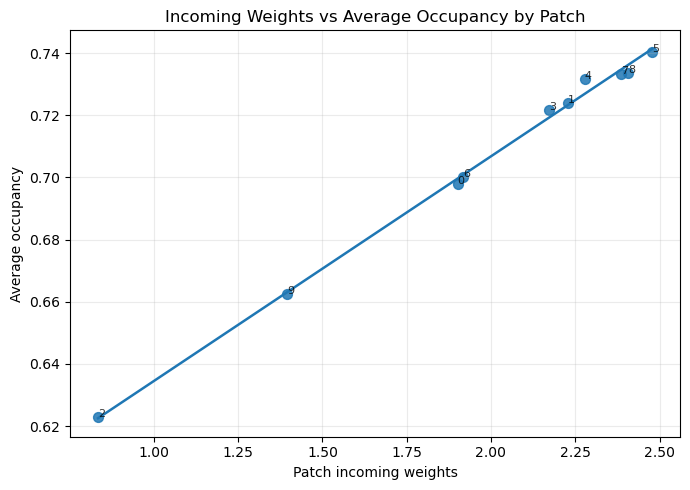

Pearson corr(incoming_w, avg occupancy) = 0.9984


In [5]:
# Plot: patch incoming weights (x) vs average occupancy (y)
import numpy as np
import matplotlib.pyplot as plt

if 'all_occupation' not in globals() or len(all_occupation) == 0:
    raise ValueError("Run the previous cell first so all_occupation is available.")

# Rebuild occupancy as (samples, patch) and average over all runs/time steps
occ_by_run = [np.asarray(arr, dtype=float).reshape(-1, env.patchnum) for arr in all_occupation]
occ_all = np.concatenate(occ_by_run, axis=0)
avg_occ_per_patch = occ_all.mean(axis=0)

# Use precomputed incoming weights if available; otherwise derive from env.w
incoming_w = np.asarray(getattr(env, 'incoming_w', np.sum(env.w, axis=1)), dtype=float)

if incoming_w.shape[0] != env.patchnum:
    raise ValueError(f"incoming_w length {incoming_w.shape[0]} does not match patchnum {env.patchnum}")

plt.figure(figsize=(7, 5))
plt.scatter(incoming_w, avg_occ_per_patch, s=50, alpha=0.85)

# Optional trend line for readability
if np.unique(incoming_w).size > 1:
    slope, intercept = np.polyfit(incoming_w, avg_occ_per_patch, 1)
    x_line = np.linspace(incoming_w.min(), incoming_w.max(), 200)
    plt.plot(x_line, slope * x_line + intercept, linewidth=1.8)

for i, (x, y) in enumerate(zip(incoming_w, avg_occ_per_patch)):
    plt.text(x, y, str(i), fontsize=8, alpha=0.8)

plt.xlabel("Patch incoming weights")
plt.ylabel("Average occupancy")
plt.title("Incoming Weights vs Average Occupancy by Patch")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Pearson corr(incoming_w, avg occupancy) = {np.corrcoef(incoming_w, avg_occ_per_patch)[0,1]:.4f}")